# Worksheet: CNN Implementation

**Topic:** CNN Implementation, LeNet-5, and Pre-Trained Models

## Learning goals

By the end of this worksheet, students should be able to:

1. Load and preprocess image data for CNNs.
2. Build a LeNet-style CNN for CIFAR-10.
3. Train and evaluate a CNN classifier.
4. Interpret learning curves and predictions.
5. Explain padding, pooling, batch normalization, and data augmentation.
6. Use a pre-trained CNN for transfer learning.
7. Fine-tune a pre-trained model for a new image task.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Notebook ready.


---

# 1. CNN implementation roadmap

In this notebook, we will work through two major implementation ideas:

1. **Train a CNN from scratch** on CIFAR-10 using a LeNet-style architecture  
2. **Use a pre-trained model** and adapt it through transfer learning

**Review:** Convolutions

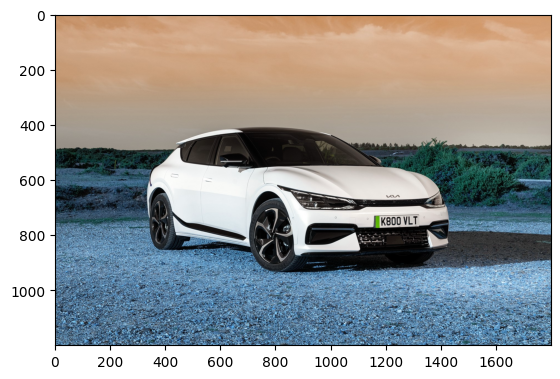

In [6]:
import cv2

## read image
car_color = cv2.imread('car_image.jpeg')
car_gray = cv2.cvtColor(car_color, cv2.COLOR_BGR2GRAY)

## plot
plt.imshow(car_color)
plt.show()

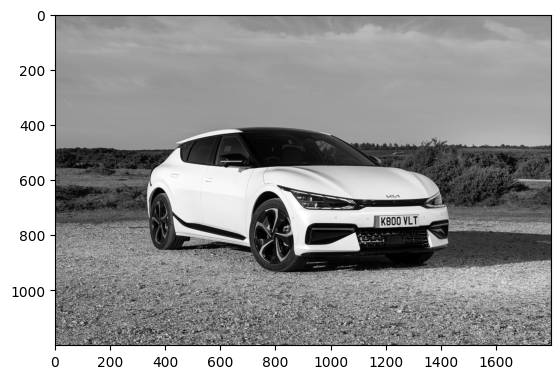

In [8]:
## plot
plt.imshow(car_gray, cmap = "gray")
plt.show()

In [9]:
## computes the whole convolution

def Convolution2D(image, kernel):
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1

    output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            # Extract the patch from the image
            patch = image[i:i + kernel_height, j:j + kernel_width]
            # Perform element-wise multiplication and sum
            output[i, j] = np.sum(patch * kernel)

    return output

In [10]:
## Edge Filter (Horizontal)
edge_kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

## Apply Edge Filter and Plot







In [11]:
## Edge Filter (Vertical)
edgev_kernel = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

## Apply Edge Filter and Plot









Pooling

Pooling is used to downsample feature maps while keeping important information.

Common types:
- **Max pooling**
- **Average pooling**

In [12]:
feature_map = np.array([
    [1, 3, 2, 0],
    [4, 6, 5, 1],
    [0, 2, 8, 7],
    [1, 3, 4, 2]
])

print(feature_map)

[[1 3 2 0]
 [4 6 5 1]
 [0 2 8 7]
 [1 3 4 2]]


In [13]:
## MAXPOOLING

def max_pooling(image, pool_size=(2, 2), stride=1):
    map_height, map_width = image.shape
    pool_height, pool_width = pool_size

    output_height = (map_height - pool_height) // stride + 1
    output_width = (map_width - pool_width) // stride + 1

    pooled_output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            # FIXED: Extract the pooling window from 'image', not 'feature_map'
            window = image[i * stride : i * stride + pool_height,
                           j * stride : j * stride + pool_width]
            # Apply max pooling
            pooled_output[i, j] = np.max(window)

    return pooled_output

In [ ]:
## Apply max pooling to feature map







In [ ]:
## Apply max pooling to car filter








In [ ]:
## AVERAGE POOLING

def average_pooling(feature_map, pool_size=(2, 2), stride=1):
    map_height, map_width = feature_map.shape
    pool_height, pool_width = pool_size

    output_height = (map_height - pool_height) // stride + 1
    output_width = (map_width - pool_width) // stride + 1

    pooled_output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            # Extract the pooling window
            window = feature_map[i * stride : i * stride + pool_height,
                                   j * stride : j * stride + pool_width]
            # Apply average pooling
            pooled_output[i, j] = np.mean(window)

    return pooled_output

In [ ]:
## Apply avg pooling to feature map






In [ ]:
## Apply avg pooling to car filter







## Practice 1A: Concept check

In your own words, what is the main difference between:

1. training a CNN from scratch  
2. using a pre-trained CNN

**Your response here:**  
1.  
2.

---

# 2. CIFAR-10 dataset

CIFAR-10 is a standard image-classification dataset with:
- 10 classes
- 60,000 color images
- image size 32 × 32 × 3

This makes it a good dataset for practicing CNN implementation.

In [23]:
import tensorflow as tf
from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import Input, Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Practice 2A: Load CIFAR-10

Load the training and test sets.

In [15]:

# TODO
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


## Practice 2B: Explore the data

CIFAR-10 class labels are:

- airplane
- automobile
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck

In [16]:

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Display the first 9 training images and their labels.

/tmp/ipykernel_31576/432396480.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


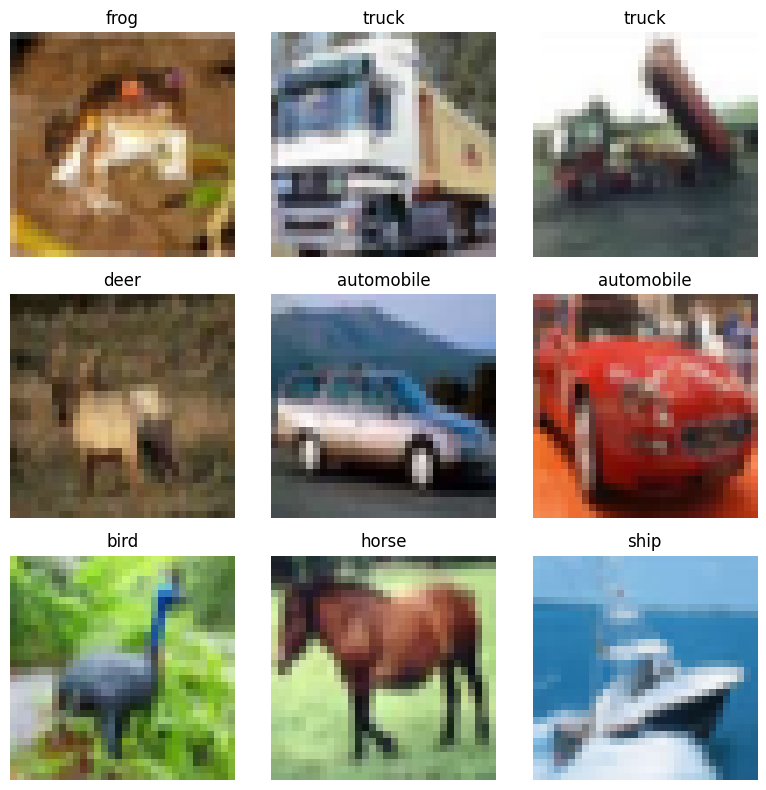

In [19]:
# TODO
plt.figure(figsize=(8, 8))
for i in range(9):
     plt.subplot(3, 3, i+1)
     plt.imshow(x_train[i])
     plt.title(class_names[int(y_train[i])])
     plt.axis("off")
plt.tight_layout()
plt.show()

## Practice 2C: Preprocess the images

Complete the preprocessing steps:
- convert images to float
- scale pixels to [0, 1]
- flatten the target array so it has shape `(n,)`

In [20]:

# TODO
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
y_train = y_train.flatten()
y_test = y_test.flatten()
print(x_train.shape, y_train.shape)


(50000, 32, 32, 3) (50000,)


---

# 3. LeNet-5 style CNN

LeNet-5 is a foundational CNN architecture. The original version was designed for grayscale handwritten digits, but we can adapt the idea to CIFAR-10.

A simple LeNet-style architecture for CIFAR-10 might use:

- Input: 32 × 32 × 3
- Conv layer
- Pooling
- Conv layer
- Pooling
- Flatten
- Dense
- Dense
- Output layer

## Practice 3A: Build a LeNet-style CNN

Build a CNN with this structure:

- input shape = `(32, 32, 3)`
- `Conv2D(6, (5,5), activation="relu", padding="same")`
- `AveragePooling2D(pool_size=(2,2))`
- `Conv2D(16, (5,5), activation="relu")`
- `AveragePooling2D(pool_size=(2,2))`
- `Flatten()`
- `Dense(120, activation="relu")`
- `Dense(84, activation="relu")`
- `Dense(10, activation="softmax")`

Compile with:
- optimizer = `"adam"`
- loss = `"sparse_categorical_crossentropy"`
- metrics = `["accuracy"]`

---

# 4. Train the LeNet-style CNN

## Practice 4A: Train the model

Train for a small number of epochs, such as:
- epochs = 5
- batch_size = 64
- validation_split = 0.1

You may add early stopping if you like.

## Practice 4B: Plot the learning curves

Plot:
- training accuracy
- validation accuracy

## Practice 4C: Evaluate the model

Evaluate the model on the test set.

## Practice 4D: Look at predictions

Display 9 test images with:
- true label
- predicted label

In [ ]:


preds = lenet_model.predict(x_test[:9], verbose=0)
pred_labels = np.argmax(preds, axis=1)
plt.figure(figsize=(9, 9))
for i in range(9):
     plt.subplot(3, 3, i+1)
     plt.imshow(x_test[i])
     plt.title(f"True: {class_names[y_test[i]]}\nPred: {class_names[pred_labels[i]]}")
     plt.axis("off")
 plt.tight_layout()
 plt.show()


---

# 5. Improving CNN training

The lecture materials highlight several practical tools used in CNN implementations:
- padding
- batch normalization
- data augmentation
- deeper architectures

## Practice 5A: Batch normalization

Why might batch normalization help CNN training?

**Your response here:**  
-

## Practice 5B: Data augmentation

What are some common image augmentation techniques?

**Your response here:**  
-

## Practice 5C: Add batch normalization

Modify the LeNet-style model so that batch normalization is applied after each convolution.

## Practice 5D: Add data augmentation

Create an `ImageDataGenerator` with a few augmentations, such as:
- horizontal flip
- small rotation
- width shift
- height shift

---

# 6. Pre-trained models and transfer learning

In many practical image tasks, we do not train a CNN from scratch.

Instead, we:
1. start with a pre-trained model
2. remove or replace the original output layer
3. train a new classifier on top of the learned image features

This is called **transfer learning**.

## Practice 6A: Concept check

Why can pre-trained models be useful?

**Your response here:**  

-

## Practice 6B: Choose a pre-trained CNN

Common pre-trained models include:
- VGG16
- ResNet50
- MobileNetV2
- EfficientNet

For this worksheet, we will use **MobileNetV2** because it is relatively lightweight.

---

# 7. Transfer learning with a pre-trained model

Pre-trained models are usually trained on ImageNet, which uses larger images such as 224 × 224.

So we need to resize CIFAR-10 images before feeding them into the model.

## Practice 7A: Resize images

Resize a small subset of CIFAR-10 images to `(224, 224)` and preprocess them for MobileNetV2.

In [ ]:
# TODO
subset_size = 5000
x_train_small = x_train[:subset_size]
y_train_small = y_train[:subset_size]
x_test_small = x_test[:1000]
y_test_small = y_test[:1000]

x_train_resized = tf.image.resize(x_train_small, (224, 224)).numpy()
x_test_resized = tf.image.resize(x_test_small, (224, 224)).numpy()

x_train_pre = preprocess_input(x_train_resized * 255.0)
x_test_pre = preprocess_input(x_test_resized * 255.0)


## Practice 7B: Build the transfer-learning model

Use:
- `MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))`
- freeze the base model
- add:
  - `GlobalAveragePooling2D()`
  - `Dense(10, activation="softmax")`

Compile with:
- optimizer = `"adam"`
- loss = `"sparse_categorical_crossentropy"`
- metrics = `["accuracy"]`

In [24]:

# TODO
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(10, activation="softmax")(x)
transfer_model = Model(inputs, outputs)

transfer_model.compile(
     optimizer="adam",
     loss="sparse_categorical_crossentropy",
     metrics=["accuracy"]
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Practice 7C: Train the transfer-learning model

Train for a small number of epochs on the resized subset.

## Practice 7D: Evaluate the transfer-learning model

Evaluate on the resized test subset.

## Practice 7E: Compare approaches

What are some tradeoffs between:
1. training LeNet-style CNN from scratch
2. using a pre-trained MobileNetV2 model

**Your response here:**  
1.  
2.

---

# 8. Optional fine-tuning

After transfer learning, a common next step is **fine-tuning**.

This means:
- unfreeze part of the pre-trained base model
- continue training with a small learning rate

## Practice 8B: Unfreeze some layers

Unfreeze the last portion of the base model and recompile with a smaller learning rate.

In [ ]:

# TODO
base_model.trainable = True

for layer in base_model.layers[:-20]:
     layer.trainable = False

 transfer_model.compile(
     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
     loss="sparse_categorical_crossentropy",
     metrics=["accuracy"])


---

# 9. Quiz-style review

Complete the following:

### Review 1
Why do we scale image pixel values before training?

### Review 2
Why is `softmax` used in the output layer for CIFAR-10?

### Review 3
What does batch normalization do?

### Review 4
What is data augmentation?

### Review 5
What is transfer learning?

### Review 6
Why do pre-trained models usually require resizing the images?

**Your responses here:**  
1.  
2.  
3.  
4.  
5.  
6.

## Quick self-check

Suggested answers:
- to keep inputs on a comparable numeric scale and help optimization
- because CIFAR-10 is a multi-class classification problem
- it normalizes intermediate activations and can stabilize training
- it increases training diversity by transforming images
- it reuses a model trained on another dataset
- because the pre-trained model expects a specific input size